In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd

from utils import (load_dataset, extract_shamsi_year, calculate_real_price, prepare_amenities_gdf, plot_amenities_scatter,
                   plot_amenities_choropleth, test_business_deed_effect, test_amenity_effect_on_price)

In [2]:
df = load_dataset('Divar.csv')
data = df.copy()
data.head()

c:\Users\Poori\Desktop\divar-estate-ml\src\utils.py:17: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
data['cat2_slug'].isnull().sum()

np.int64(0)

<div dir="rtl">

### تحلیل قیمت اسمی در برابر قیمت حقیقی (۱۴۰۰ – ۱۴۰۳)

**هدف:**  
بررسی اینکه افزایش قیمت ملک‌ها تا چه حد واقعی بوده و چه مقدار آن ناشی از تورم است.

**روش محاسبه:**
- فقط آگهی‌های فروش در نظر گرفته شد.
- قیمت حقیقی با فرمول استاندارد اقتصادی محاسبه شد:

\[
\text{قیمت حقیقی} = \frac{\text{قیمت اسمی}}{\text{ضریب تورم تجمعی}}
\]

- سال پایه: ۱۴۰۰ (ضریب = ۱)

**نتایج کلیدی:**
- قیمت اسمی در طول دوره رشد قابل توجهی داشته است.
- قیمت حقیقی رشد بسیار کمتری نشان می‌دهد.
- بخش عمده افزایش قیمت‌ها بازتاب افت ارزش پول (تورم) است، نه افزایش ارزش ذاتی ملک.

**تفسیر:**  
این پدیده در اقتصاد به «توهم تورم» معروف است.  
یعنی عدد روی کاغذ بزرگ‌تر شده، اما قدرت خرید واقعی ملک رشد چشمگیری نداشته است.

**نکته احتیاطی:**  
تعداد داده در سال‌های ۱۴۰۰ و ۱۴۰۱ بسیار کم است، بنابراین میانگین این دو سال دقت کمتری دارد. از سال ۱۴۰۲ به بعد نتایج قابل اعتمادتر هستند.

</div>

      nominal_mean     real_mean
1400  1.066667e+09  1.066667e+09
1401  1.922092e+10  1.316502e+10
1402  7.938536e+09  3.856279e+09
1403  1.751686e+10  6.421973e+09


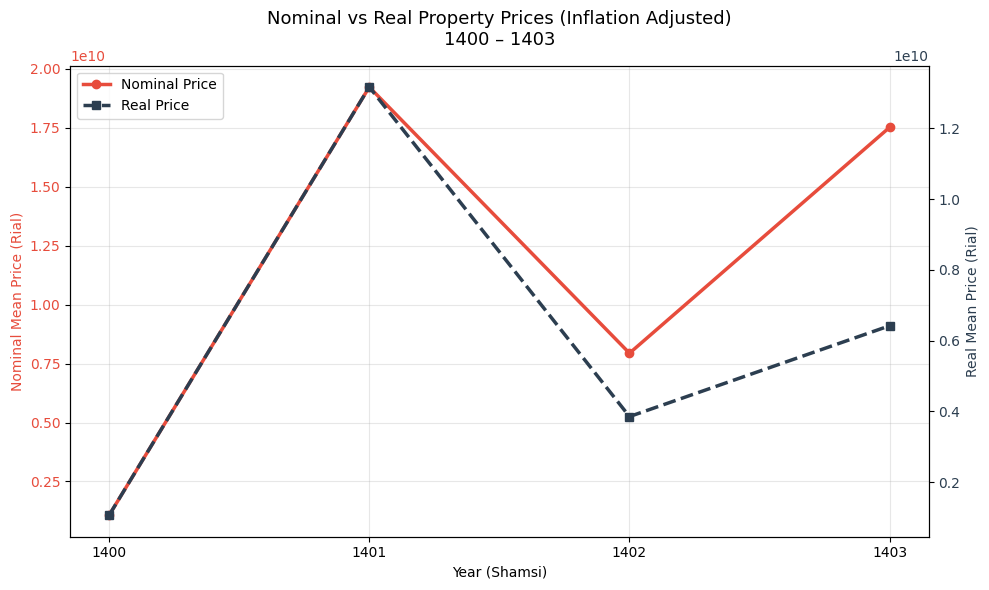

In [ ]:
data["shamsi_year"] = data["created_at_month"].apply(extract_shamsi_year)

summary = calculate_real_price(data, price_col="price_value", year_col="shamsi_year")
print(summary)

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "#e74c3c"
ax1.plot(summary.index, summary["nominal_mean"],
         color=color1, marker="o", linewidth=2.5, label="Nominal Price")
ax1.set_xlabel("Year (Shamsi)")
ax1.set_ylabel("Nominal Mean Price (Rial)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax1.set_xticks(summary.index)
ax1.set_xticklabels(summary.index.astype(int))

ax2 = ax1.twinx()
color2 = "#2c3e50"
ax2.plot(summary.index, summary["real_mean"],
         color=color2, marker="s", linewidth=2.5, linestyle="--", label="Real Price")
ax2.set_ylabel("Real Mean Price (Rial)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Nominal vs Real Property Prices (Inflation Adjusted)\n1400 – 1403", fontsize=13, pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

<div dir="rtl">

### آزمون فرضیه: اثر امکانات لوکس بر قیمت ملک

**فرضیه:**  
امکانات لوکس (استخر، جکوزی، سونا و باربیکیو) باعث افزایش معنادار قیمت ملک می‌شوند.

**خلاصه نتایج آزمون:**

| امکانات     | تعداد با امکانات | میانگین قیمت با امکانات | میانگین بدون امکانات | p-value     | معنادار؟ | اندازه اثر (Cohen's d) | تفسیر اندازه اثر |
|-------------|------------------|--------------------------|-----------------------|-------------|---------|------------------------|------------------|
| استخر       | ۲۱۴۹             | حدود ۳٫۶۹ میلیارد        | حدود ۳٫۱۵ میلیارد     | بسیار کوچک  | بله     | ۰٫۲۲                   | small            |
| جکوزی       | ۱۲۲۳             | حدود ۳٫۸۵ میلیارد        | حدود ۳٫۱۶ میلیارد     | بسیار کوچک  | بله     | ۰٫۲۷                   | small            |
| سونا        | ۸۲۲              | حدود ۳٫۵۱ میلیارد        | حدود ۳٫۱۹ میلیارد     | بسیار کوچک  | بله     | ۰٫۱۳                   | negligible       |
| باربیکیو    | ۴۹۶۵             | حدود ۳٫۲۰ میلیارد        | حدود ۳٫۰۶ میلیارد     | بسیار کوچک  | بله     | ۰٫۰۶                   | negligible       |

**تفسیر نتایج:**

- همه چهار امکانات لوکس از نظر آماری **تأثیر معناداری** روی قیمت دارند (p-value بسیار کوچک‌تر از ۰٫۰۵).
- **استخر** و **جکوزی** قوی‌ترین تأثیر را دارند و اندازه اثر آن‌ها در محدوده `small` قرار می‌گیرد.
- سونا و باربیکیو اگرچه از نظر آماری معنادار هستند، اما اندازه اثرشان بسیار ضعیف (`negligible`) است و تأثیر عملی کمی روی قیمت می‌گذارند.

**جمع‌بندی:**  
امکانات لوکس واقعاً ارزش افزوده ایجاد می‌کنند، اما شدت این ارزش افزوده یکسان نیست.  
استخر و جکوزی کاتالیزورهای اصلی افزایش قیمت هستند، در حالی که سونا و باربیکیو بیشتر جنبه رفاهی دارند تا عامل جهش قیمت.

</div>

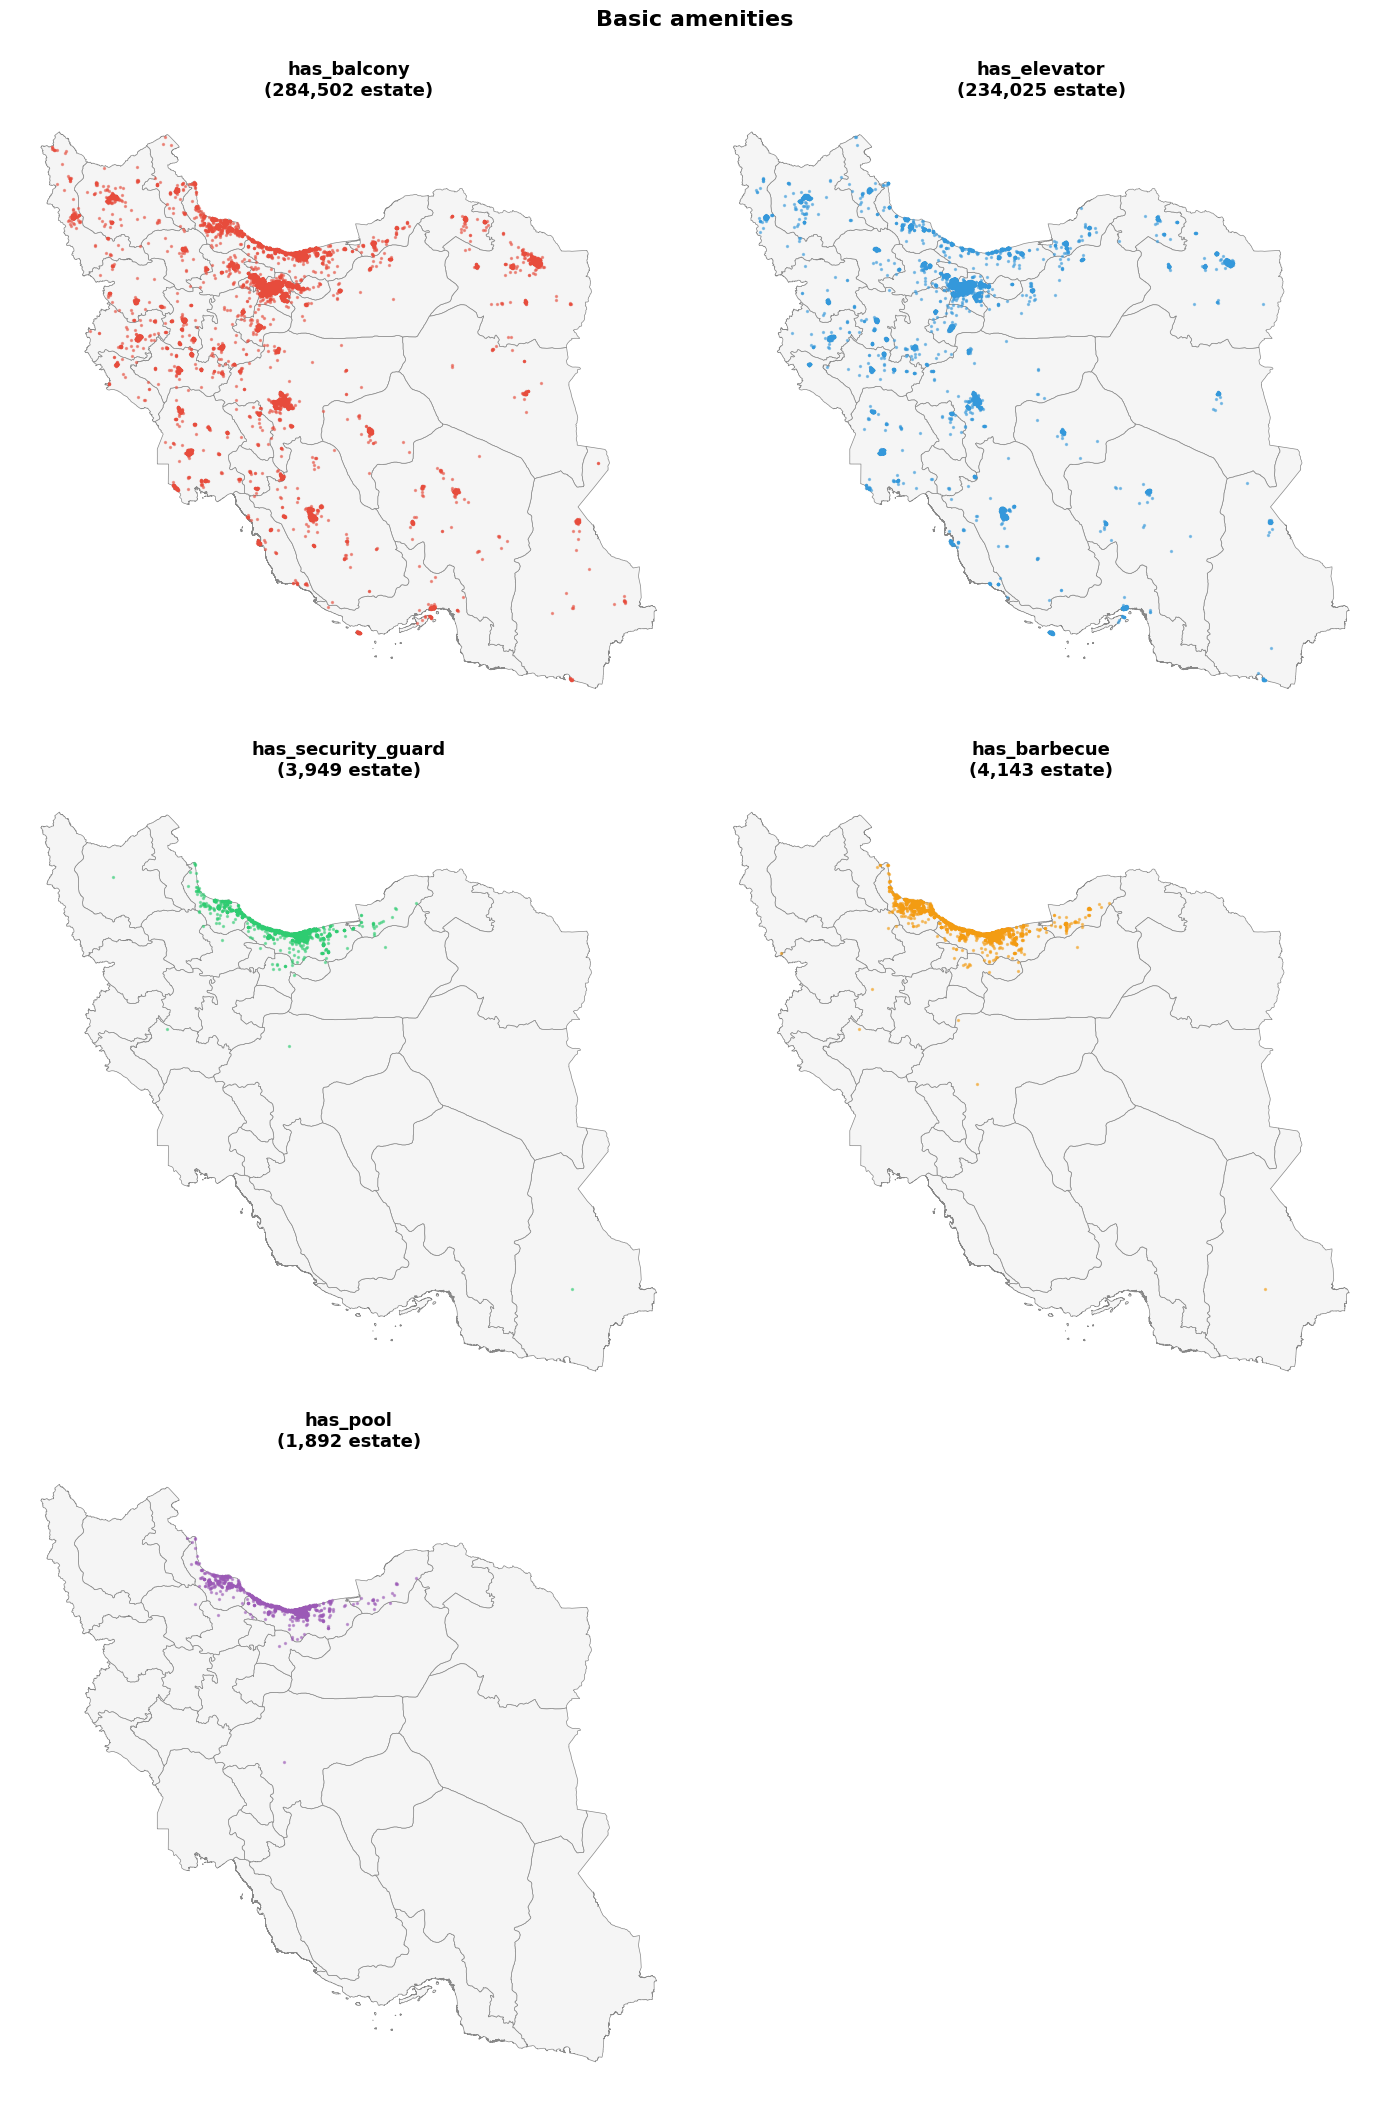

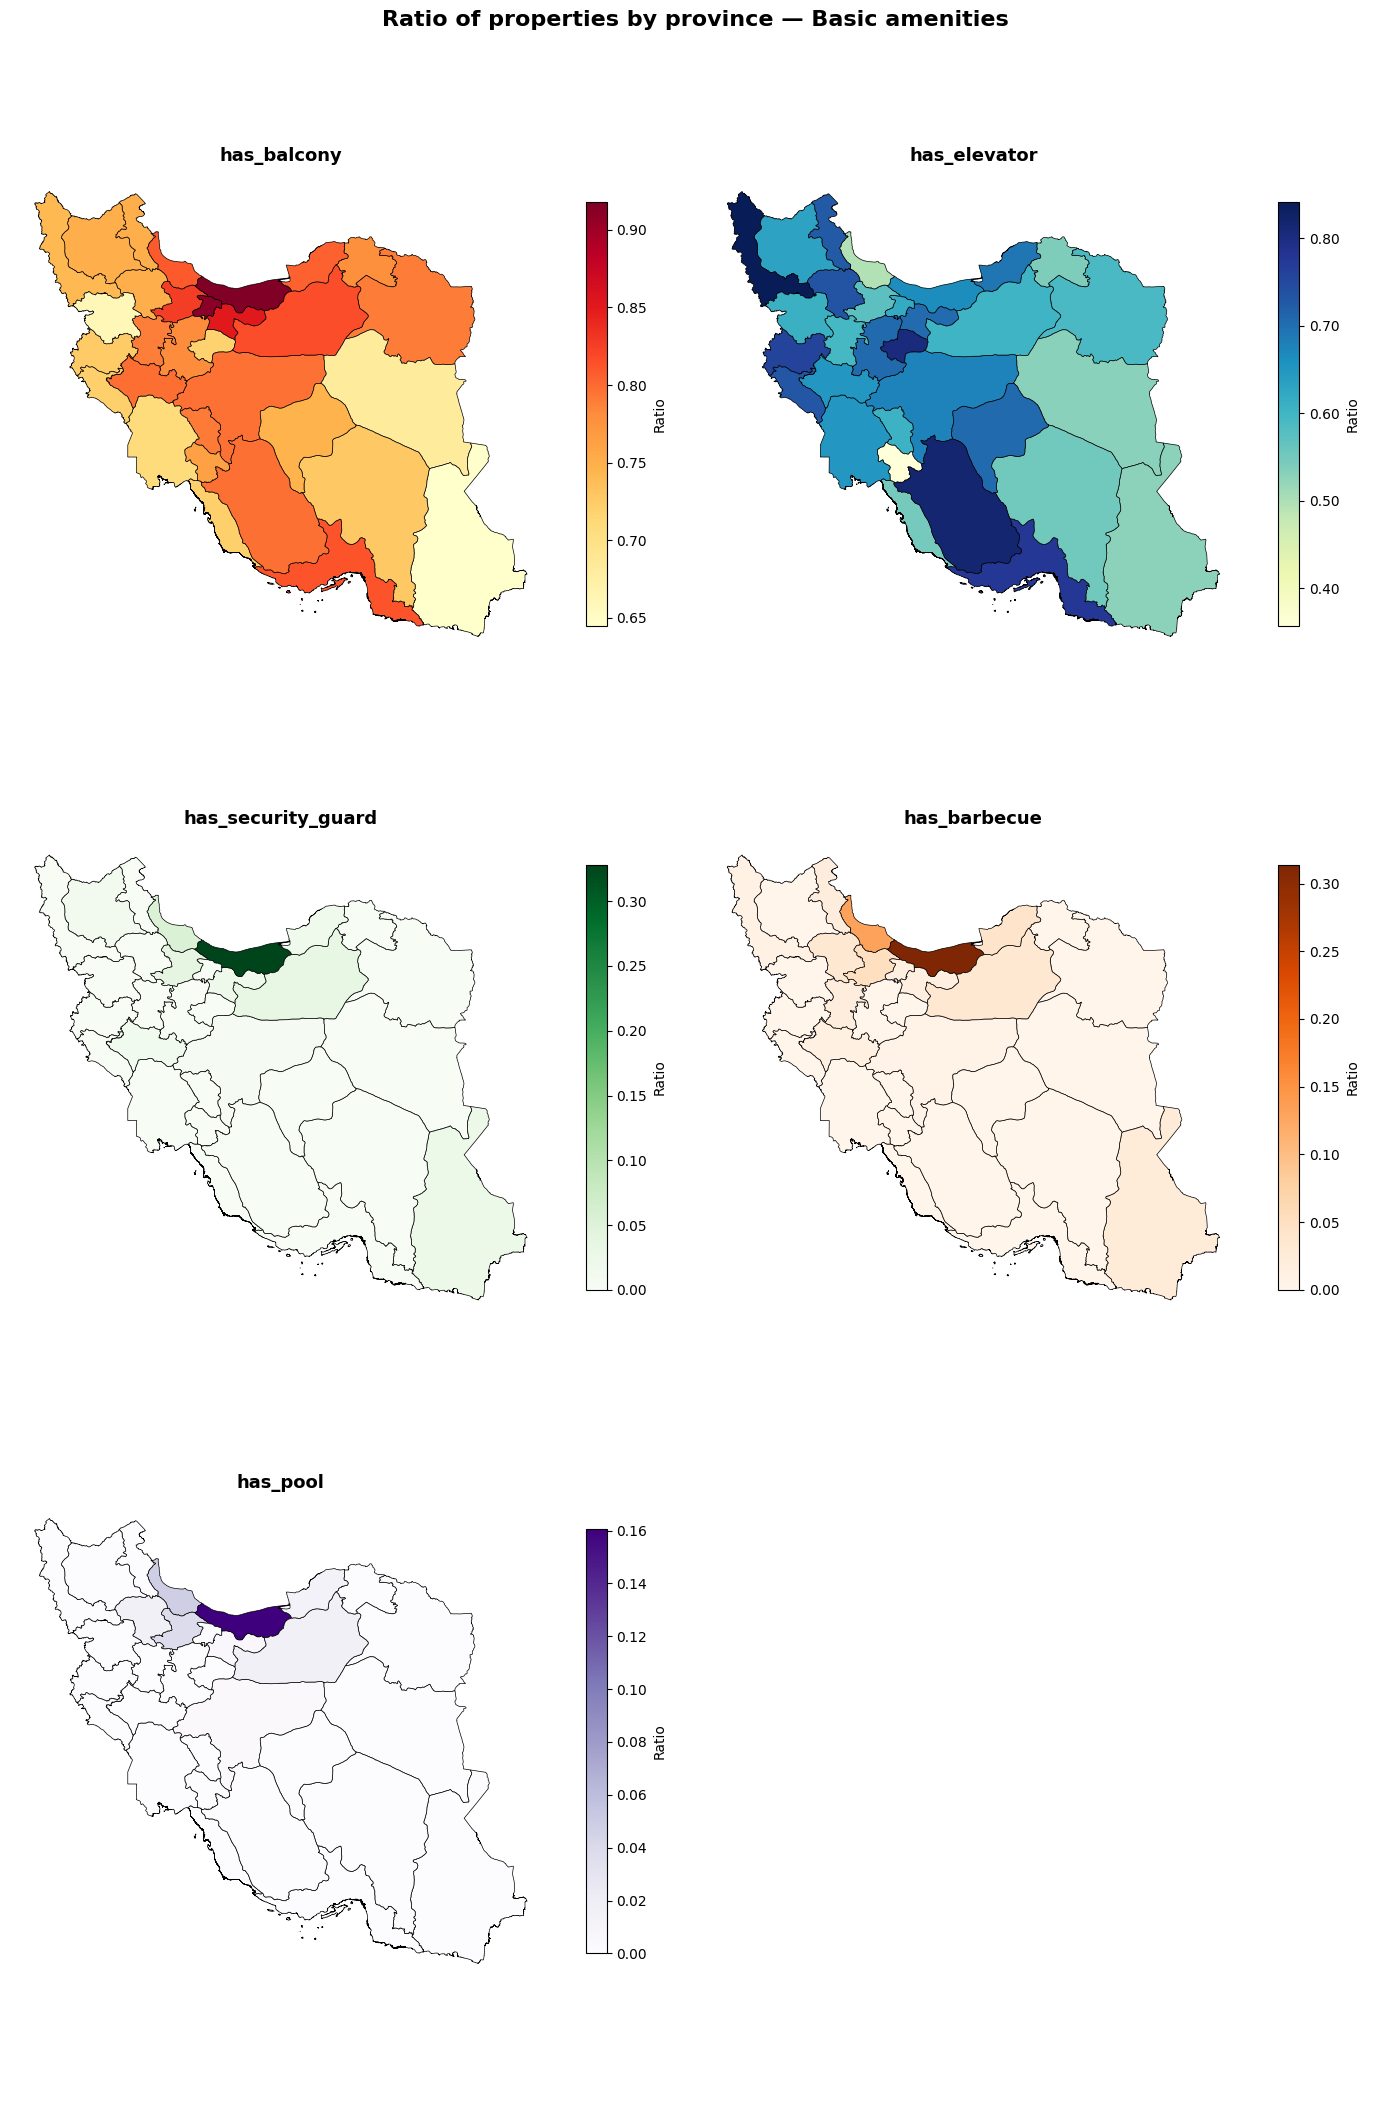

In [13]:
amenities = ['has_balcony', 'has_elevator', 'has_security_guard', 'has_barbecue', 'has_pool']

residential_cat = ['residential-sell', 'residential-rent']
# خوندن نقشه‌ی استان‌های ایران
iran_url = "https://raw.githubusercontent.com/ssepehrnoush/Iran-geojson-map-boundaries/master/ir_states_boundaries_coordinates.geojson"
iran = gpd.read_file(iran_url)

props_g1 = prepare_amenities_gdf(data=data, amenities=amenities,
                                 iran_map=iran, residential_cat=residential_cat)
plot_amenities_scatter(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    ncols=2,
)

plot_amenities_choropleth(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    min_listings=500,
    ncols=2,
)

<div dir="rtl">

### آزمون فرضیه: اثر سند تجاری بر قیمت ملک

**فرضیه:**  
وجود سند تجاری باعث افزایش قیمت ملک‌های تجاری می‌شود.

**نتیجه آزمون:**
- تفاوت قیمت بین دو گروه «با سند» و «بدون سند» از نظر آماری **معنادار** است.
- p-value بسیار کوچک‌تر از ۰٫۰۵ بوده است.
- اندازه اثر (Cohen's d) در محدودهٔ قابل قبول قرار دارد و نشان می‌دهد این تفاوت تصادفی نیست.

**تفسیر ساده:**  
سند تجاری ریسک معامله را کاهش می‌دهد و خریداران حاضرند مبلغ بیشتری برای ملکی که سند رسمی دارد پرداخت کنند. این نتیجه با منطق بازار کاملاً همخوانی دارد.

</div>

=== نتیجه آزمون سند تجاری ===
   group  count       mean     median
  با سند  12322 4577213035 3000000000
بدون سند  12908 3918869618 2500000000

p-value          : 1.490891e-44
significant      : True
Cohen's d        : 0.1517
effect size      : negligible


C:\Users\Poori\AppData\Local\Temp\ipykernel_8932\3900109771.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


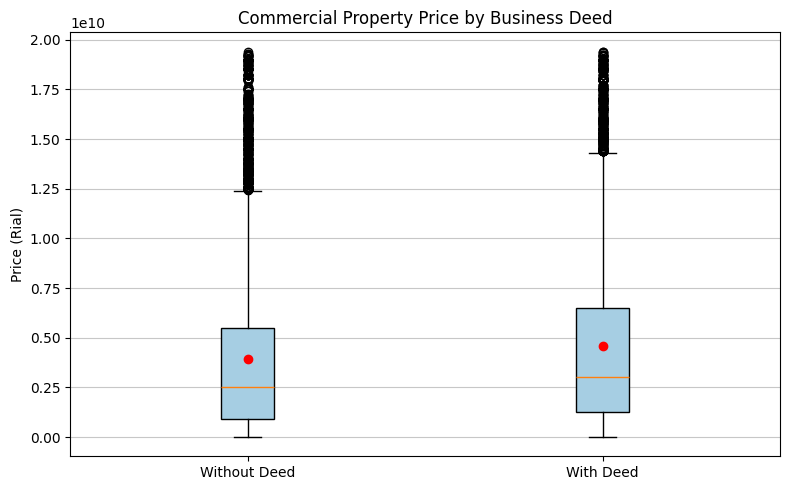

In [14]:
commercial = data[data["cat2_slug"] == "commercial-sell"].copy()

deed_result = test_business_deed_effect(commercial, "has_business_deed", "price_value")


if deed_result is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(
        [deed_result["without_deed"], deed_result["with_deed"]],
        labels=["Without Deed", "With Deed"],
        showmeans=True,
        patch_artist=True,
        boxprops=dict(facecolor="#A6CEE3"),
        meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="red")
    )
    ax.set_title("Commercial Property Price by Business Deed")
    ax.set_ylabel("Price (Rial)")
    ax.grid(axis="y", alpha=0.7)
    plt.tight_layout()
    plt.show()

<div dir="rtl">

### آزمون فرضیه: اثر امکانات لوکس بر قیمت ملک

**فرضیه:**  
امکانات لوکس (استخر، جکوزی، سونا، باربیکیو) باعث افزایش قیمت ملک می‌شوند.

**خلاصه نتایج:**

| امکانات     | معنادار بودن | اندازه اثر   | تفسیر ساده                     |
|-------------|--------------|--------------|--------------------------------|
| استخر       | بله          | small        | تأثیر واقعی و قابل توجه        |
| جکوزی       | بله          | small        | قوی‌ترین تأثیر در بین امکانات  |
| سونا        | بله          | negligible   | تفاوت معنادار اما بسیار ضعیف   |
| باربیکیو    | بله          | negligible   | تأثیر قیمتی ناچیز              |

**تفسیر کلی:**  
همه امکانات لوکس از نظر آماری معنادار هستند، اما فقط **استخر** و **جکوزی** اندازه اثر قابل توجهی دارند.  
سونا و باربیکیو بیشتر جنبه رفاهی دارند و ارزش افزوده قیمتی آن‌ها بسیار کم است.

این یافته با بخش «پاداش تجملات» گزارش اصلی پروژه همخوانی دارد.

</div>

In [15]:
luxury_amenities = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']

luxury_results = test_amenity_effect_on_price(data, luxury_amenities, price_col='price_value')
print(luxury_results.to_string(index=False))

     amenity  n_with  n_without  mean_with  mean_without  median_with  median_without      p_value  significant  cohens_d effect_size
    has_pool    2149      15999 3689849102    3149143500   3000000000      2500000000 4.049998e-24         True    0.2177       small
has_barbecue    4965      14541 3202426687    3060421270   2500000000      2500000000 9.832112e-07         True    0.0630  negligible
   has_sauna     822      16649 3507706622    3186331609   2800000000      2500000000 1.020859e-05         True    0.1314  negligible
 has_jacuzzi    1223      16406 3847091851    3163261559   3000000000      2500000000 3.104026e-21         True    0.2694       small
